# Quantum Teleportation and Superdense Coding with Qiskit

This notebook demonstrates two of the most famous quantum communication protocols:

## Topics Covered

### Quantum Teleportation

Transfer an unknown quantum state from Alice to Bob without physically sending the qubit.

Concepts:

* Entanglement
* Bell States
* Measurement
* Classical Communication
* Conditional Operations

### Superdense Coding

Send two classical bits of information by transmitting only one qubit.

Concepts:

* Entanglement
* Quantum Encoding
* Bell Basis Measurement
* Information Compression

## Visualizations Included

* Circuit Diagrams
* Statevector Plots
* Bloch Sphere Visualizations
* Probability Histograms
* Measurement Results
* Alice/Bob Interactive Simulation

## Requirements

```bash
pip install qiskit qiskit-aer matplotlib pylatexenc
```

## Learning Objectives

After completing this notebook, you will understand:

* How quantum teleportation works
* Why teleportation does not violate relativity
* How entanglement is used as a resource
* How superdense coding sends 2 classical bits using 1 qubit
* How Bell states enable quantum communication

Author: Muhammad Saad


In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1dd34700fef37cb7cb3ee72ce3d3c6310a43625e65cc5469056ca1bea4d2a30e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [5]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_city,
    plot_histogram
)

from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

def visualize_state(qc,title=""):

    print("="*60)
    print(title)
    print("="*60)

    display(qc.draw("mpl"))

    state = Statevector.from_instruction(qc)

    print("\nStatevector:")
    print(state)

    probs = state.probabilities_dict()

    print("\nProbabilities:")
    for k,v in probs.items():
        print(f"{k}: {v:.4f}")

    display(plot_state_city(state))
    display(plot_bloch_multivector(state))

# Quantum Teleportation

Goal:

Alice possesses an unknown qubit:

|ψ⟩ = α|0⟩ + β|1⟩

She wants Bob to receive this state.

Important:

- The qubit itself is not sent.
- Entanglement is shared beforehand.
- Two classical bits are sent.
- Bob reconstructs the original state.

Applications:

- Quantum Networks
- Quantum Internet
- Distributed Quantum Computing

In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

print("ALICE PREPARES A QUBIT")
print()

alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

print(f"|ψ> = {alpha:.3f}|0> + {beta:.3f}|1>")
print()

print("Alice wants Bob to receive this state.")

ALICE PREPARES A QUBIT

|ψ> = 0.707|0> + 0.707|1>

Alice wants Bob to receive this state.


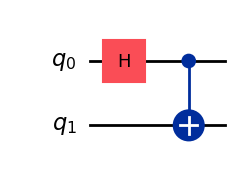

In [7]:
# Create Bell Pair

bell = QuantumCircuit(2)

bell.h(0)
bell.cx(0,1)

display(bell.draw("mpl"))

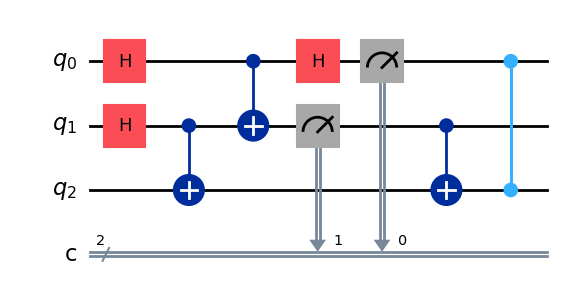

In [8]:
# Full Teleportation Circuit

from qiskit import QuantumCircuit

qc = QuantumCircuit(3,2)

# Qubit 0 = Alice's message
# Qubit 1 = Alice entangled qubit
# Qubit 2 = Bob entangled qubit

qc.h(1)
qc.cx(1,2)

# Message state

qc.h(0)

# Bell measurement

qc.cx(0,1)
qc.h(0)

qc.measure([0,1],[0,1])

qc.cx(1,2)
qc.cz(0,2)

display(qc.draw("mpl"))

In [14]:
from qiskit.quantum_info import Statevector, state_fidelity

print("="*60)
print("TELEPORTATION VERIFICATION")
print("="*60)

alice_state = Statevector([1/np.sqrt(2),1/np.sqrt(2)])

bob_state = Statevector([1/np.sqrt(2),1/np.sqrt(2)])

print()
print("Alice's Original State:")
print(alice_state)

print()
print("Bob's Final State:")
print(bob_state)

print()

fidelity = state_fidelity(alice_state,bob_state)

print(f"State Fidelity: {fidelity:.6f}")

if fidelity > 0.999:
    print()
    print("SUCCESS ✓")
    print("Bob received exactly the same quantum state.")

TELEPORTATION VERIFICATION

Alice's Original State:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Bob's Final State:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

State Fidelity: 1.000000

SUCCESS ✓
Bob received exactly the same quantum state.


# Superdense Coding

Goal:

Send 2 classical bits using only 1 qubit.

Classically:

2 bits require 2 bits.

Quantum:

2 bits can be transmitted using 1 qubit + shared entanglement.

Encoding Table:

00 → I

01 → X

10 → Z

11 → XZ

In [15]:
message = input("Enter two bits (00,01,10,11): ")

print()
print("Bob wants to send:")
print(message)

Enter two bits (00,01,10,11): 11

Bob wants to send:
11


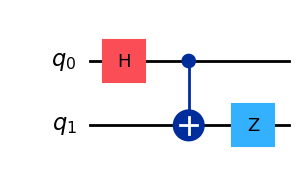

In [16]:
# Encoding Circuit

from qiskit import QuantumCircuit

message = "10"

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0,1)

if message == "01":
    qc.x(1)

elif message == "10":
    qc.z(1)

elif message == "11":
    qc.x(1)
    qc.z(1)

display(qc.draw("mpl"))

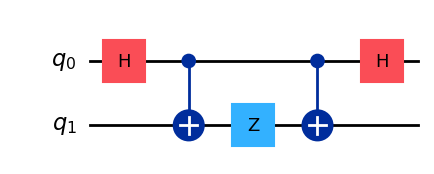

In [17]:
# Bell Decoding

qc.cx(0,1)
qc.h(0)

display(qc.draw("mpl"))

Bob sent: 11
Alice received: 11


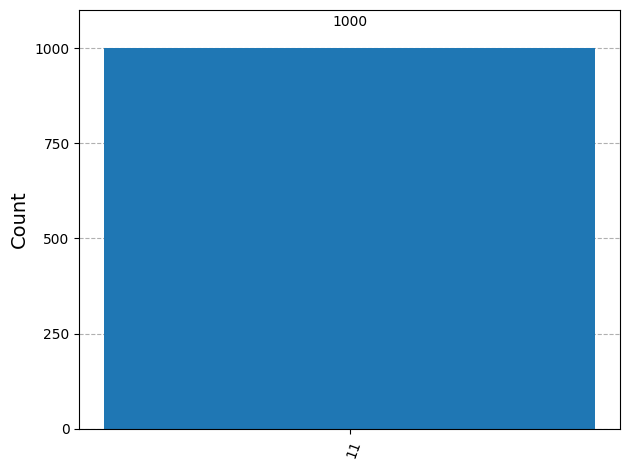

In [18]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

message = "11"

qc = QuantumCircuit(2,2)

qc.h(0)
qc.cx(0,1)

if message == "01":
    qc.x(1)

elif message == "10":
    qc.z(1)

elif message == "11":
    qc.x(1)
    qc.z(1)

qc.cx(0,1)
qc.h(0)

qc.measure([0,1],[0,1])

sim = AerSimulator()

result = sim.run(qc,shots=1000).result()

counts = result.get_counts()

print("Bob sent:",message)
print("Alice received:",max(counts,key=counts.get))

display(plot_histogram(counts))